In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

In [15]:
image = cv2.imread("Data/cat_picture_4.jpg")

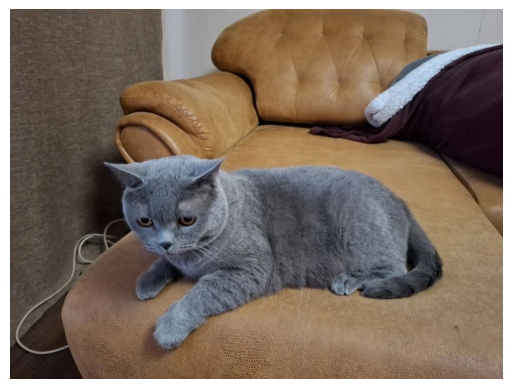

In [16]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off') 
plt.show()

## Пороговая фильтрация

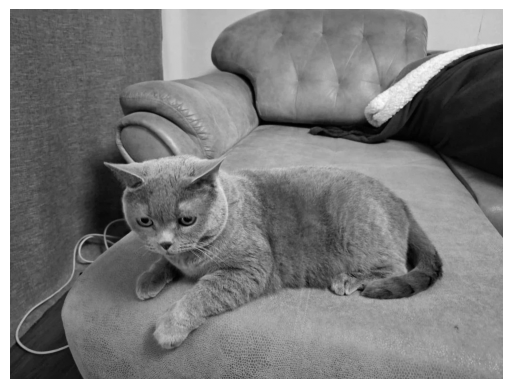

In [4]:

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_image, cmap="gray")
plt.axis("off")
plt.show()

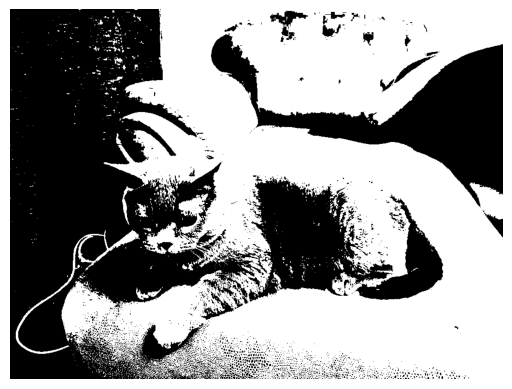

In [5]:
ret, thresh_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(thresh_image, cmap="gray")
plt.axis('off')
plt.show()

## Фильтрация через HSV

In [4]:
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

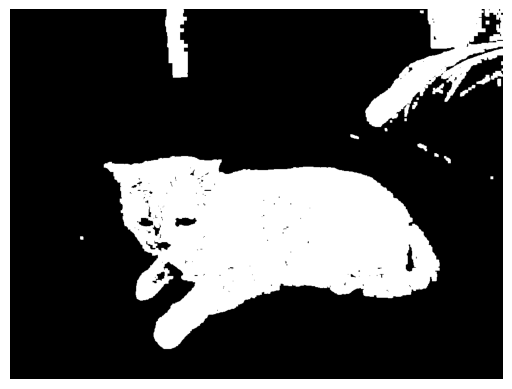

In [5]:
lower_gray = np.array([30,10,15])
upper_gray = np.array([180, 90, 255])

mask_hsv_image = cv2.inRange(hsv_image, lower_gray, upper_gray)

kernel = np.ones((5,5), dtype=np.uint8)
final_mask = cv2.morphologyEx(mask_hsv_image, cv2.MORPH_OPEN, kernel)

plt.imshow(final_mask, cmap="gray")
plt.axis("off")
plt.show()

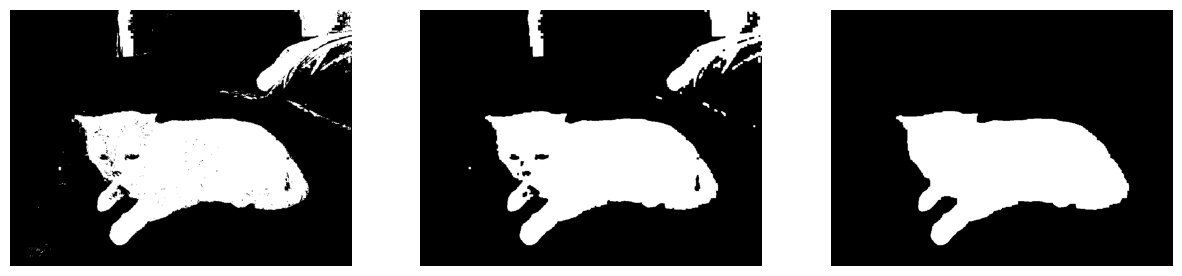

In [6]:
fig, axis = plt.subplots(1, 3, figsize = (15, 10))

lower_gray = np.array([30, 10,15])
upper_gray = np.array([180, 90, 255])

mask_hsv_image = cv2.inRange(hsv_image, lower_gray, upper_gray)

axis[0].imshow(mask_hsv_image, cmap="gray")
axis[0].axis("off")

kernel = np.ones((3,3), dtype=np.uint8)
final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE ,kernel, iterations=2)
axis[1].imshow(final_mask, cmap="gray")
axis[1].axis("off")

contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
clean_cat_mask = np.zeros_like(final_mask)

if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    
    cv2.drawContours(clean_cat_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

kernel = np.ones((5,5), dtype=np.uint8)
clean_cat_mask = cv2.morphologyEx(clean_cat_mask, cv2.MORPH_CLOSE, kernel, iterations=4)

axis[2].imshow(clean_cat_mask, cmap="gray")
axis[2].axis("off")
plt.show()

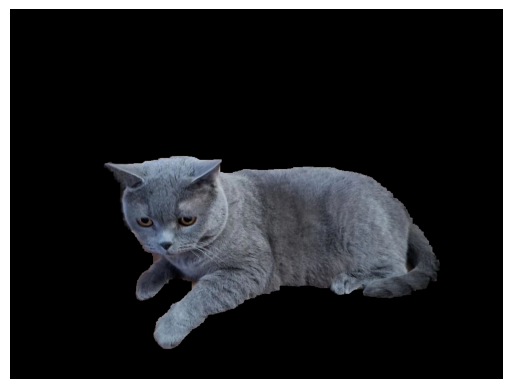

In [17]:
result_hsv_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=clean_cat_mask)
plt.imshow(result_hsv_rgb)
plt.axis("off")
plt.show()

## GrabCut

In [18]:
%matplotlib qt
box_coords = None
def on_select(eclick, erelease):
    global box_coords

    x1, y1 = int(eclick.xdata), int(eclick.ydata)
    x2, y2 = int(erelease.xdata), int(erelease.ydata)

    x = min(x1, x2)
    y = min(y1, y2)
    w = abs(x1 - x2)
    h = abs(y1 - y2)

    box_coords = (x, y, w, h)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
fig, axis = plt.subplots(figsize=(8,6))
axis.imshow(image_rgb)
axis.axis("off")
axis.set_title("Выдели прямоугольник")

rectangle = RectangleSelector(
    axis,
    on_select,
    button=[1],
    minspanx=5, minspany=5,
    interactive=True,
)

plt.show()

In [19]:
print(box_coords)
#(179, 282, 736, 426)

(163, 289, 755, 422)


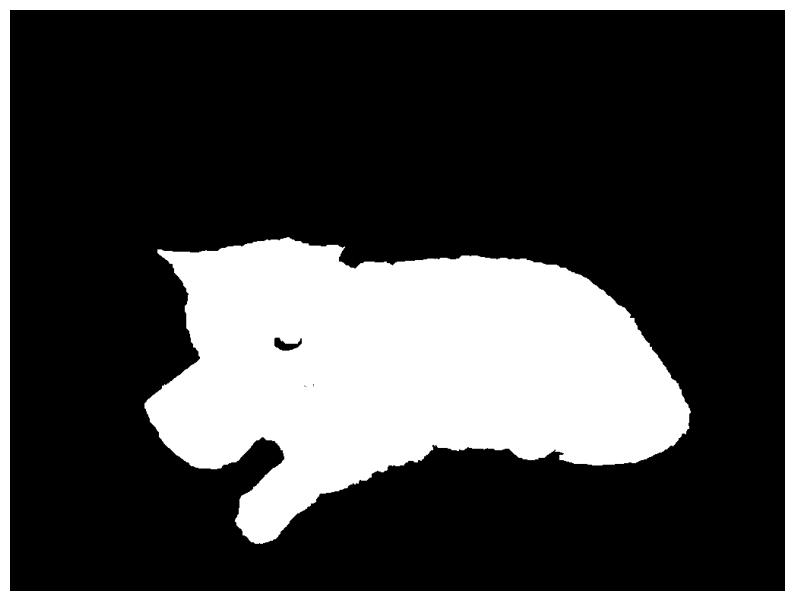

In [20]:
%matplotlib inline
mask = np.zeros(image.shape[:2], dtype=np.uint8)
bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)

cv2.setRNGSeed(42)                 
cv2.grabCut(
    img=image,
    mask=mask,
    rect=box_coords,
    bgdModel=bgdModel,
    fgdModel=fgdModel,
    iterCount=5,
    mode=cv2.GC_INIT_WITH_RECT
)

maskGrabCut = np.where((mask==1) | (mask==3), 255, 0).astype(np.uint8)
plt.close("all")

fig, axis = plt.subplots(figsize=(10,9))
axis.imshow(maskGrabCut, cmap="gray")
axis.axis("off")
plt.show()

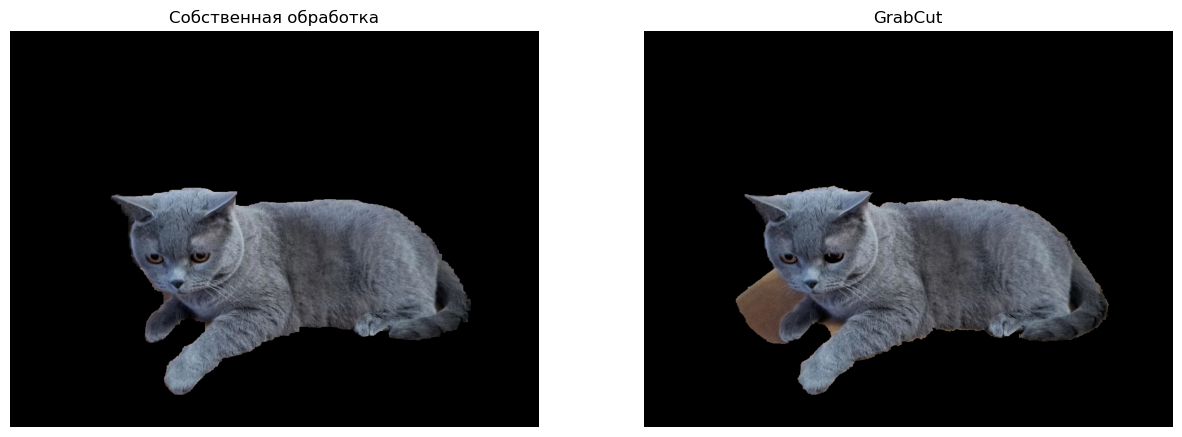

In [21]:
fig, axis = plt.subplots(1, 2, figsize=(15,9))

result_grab = cv2.bitwise_and(image_rgb, image_rgb, mask=maskGrabCut)
axis[0].set_title("Собственная обработка")
axis[0].imshow(result_hsv_rgb)
axis[0].axis("off")

axis[1].set_title("GrabCut")
axis[1].imshow(result_grab)
axis[1].axis("off")
plt.show()

## Генерация

In [12]:
class AugmentationGenerator():
    def __init__(self, random_state=42):
        self.random_state = random_state

    def _rotate_image(self, img, mask, angle):
        h, w = img.shape[:2]
        center = (w//2, h//2)

        M = cv2.getRotationMatrix2D(center, angle, scale=1.0)

        angle_rad = np.deg2rad(angle)
        cos = np.abs(np.cos(angle_rad))
        sin = np.abs(np.sin(angle_rad))
        new_w = int((h * sin) + (w * cos))
        new_h = int((h * cos) + (w * sin))

        M[0, 2] += (new_w / 2) - center[0]
        M[1, 2] += (new_h / 2) - center[1]

        rotated_img = cv2.warpAffine(
            img, M, (new_w, new_h), 
            flags=cv2.INTER_LINEAR, 
            borderMode=cv2.BORDER_CONSTANT, 
            borderValue=(0, 0, 0)
        )
        
        rotated_mask = cv2.warpAffine(
            mask, M, (new_w, new_h), 
            flags=cv2.INTER_NEAREST, 
            borderMode=cv2.BORDER_CONSTANT, 
            borderValue=0
        )
    
        return rotated_img, rotated_mask

    def _rotate_keep_size(self, img, mask, angle):
        h_target, w_target = img.shape[:2]
        
        expanded_img, expanded_mask = self._rotate_image(img, mask, angle)
        final_img = cv2.resize(expanded_img, (w_target, h_target), interpolation=cv2.INTER_LINEAR)
        
        final_mask = cv2.resize(expanded_mask, (w_target, h_target), interpolation=cv2.INTER_NEAREST)
        
        return final_img, final_mask

    def _scale(self, img, mask):
        h, w = img.shape[:2]
        koef = np.random.uniform(low=0.05, high=0.2, size=2)

        top = int(h * koef[0])
        bottom = int(h * (1.0 - koef[0]))
        left = int(w * koef[1])
        right = int(w * (1.0 - koef[1]))
        cropped_img = img[top:bottom, left:right]
        cropped_mask = mask[top:bottom, left:right]

        scale_img = cv2.resize(cropped_img, (w, h), interpolation=cv2.INTER_LINEAR)
        scale_mask = cv2.resize(cropped_mask, (w, h), interpolation=cv2.INTER_NEAREST)

        return scale_img, scale_mask
    
    def _shift(self, img, mask):
        h, w = img.shape[:2]

        dx = np.random.randint(-int(w*0.1), int(w*0.1))
        dy = np.random.randint(-int(h*0.1), int(h*0.1))
        M_shift = np.float32([[1, 0, dx],
                              [0, 1, dy]])

        shifted_img = cv2.warpAffine(img, M_shift, (w, h), flags=cv2.INTER_LINEAR)
        shifted_mask = cv2.warpAffine(mask, M_shift, (w, h), flags=cv2.INTER_NEAREST)

        return shifted_img, shifted_mask

    def transform(self, img, mask, app_count=30, shuffle=True, keep_origin=True):
        koef_on_rotating = 0.5 * app_count
        koef_on_flip_rotating = 0.3 * app_count
        koef_on_scaling = 0.1 * app_count
        koef_on_shift = 0.1 * app_count

        list_augmentation_image = []
        list_augmentation_mask = []

        np.random.seed(self.random_state)
        for angle in range(15, 345, int(360/koef_on_rotating)):
            rotate_image, rotate_mask = self._rotate_keep_size(img, mask, angle)

            list_augmentation_image.append(rotate_image)
            list_augmentation_mask.append(rotate_mask)

        flipped_img = cv2.flip(img, 1)
        flipped_mask = cv2.flip(mask, 1)
        for angle in range(15, 345, int(360/koef_on_flip_rotating)):
            rotate_image, rotate_mask = self._rotate_keep_size(flipped_img, flipped_mask, angle)

            list_augmentation_image.append(rotate_image)
            list_augmentation_mask.append(rotate_mask)

        for i in range(int(koef_on_scaling)):
            scaled_image, scaled_mask = self._scale(img, mask)

            list_augmentation_image.append(scaled_image)
            list_augmentation_mask.append(scaled_mask)
        
        for i in range(int(koef_on_shift)):
            shifted_image, shifted_mask = self._shift(img, mask)

            list_augmentation_image.append(shifted_image)
            list_augmentation_mask.append(shifted_mask)


        if keep_origin:
            list_augmentation_image.append(img)
            list_augmentation_mask.append(mask)

        array_augmentation_image = np.array(list_augmentation_image, dtype=np.uint8)
        array_augmentation_mask = np.array(list_augmentation_mask, dtype=np.uint8)

        if shuffle:
            shuffle_index = np.random.permutation(len(list_augmentation_image))

            array_augmentation_image = array_augmentation_image[shuffle_index]
            array_augmentation_mask = array_augmentation_mask[shuffle_index]

        return array_augmentation_image, array_augmentation_mask



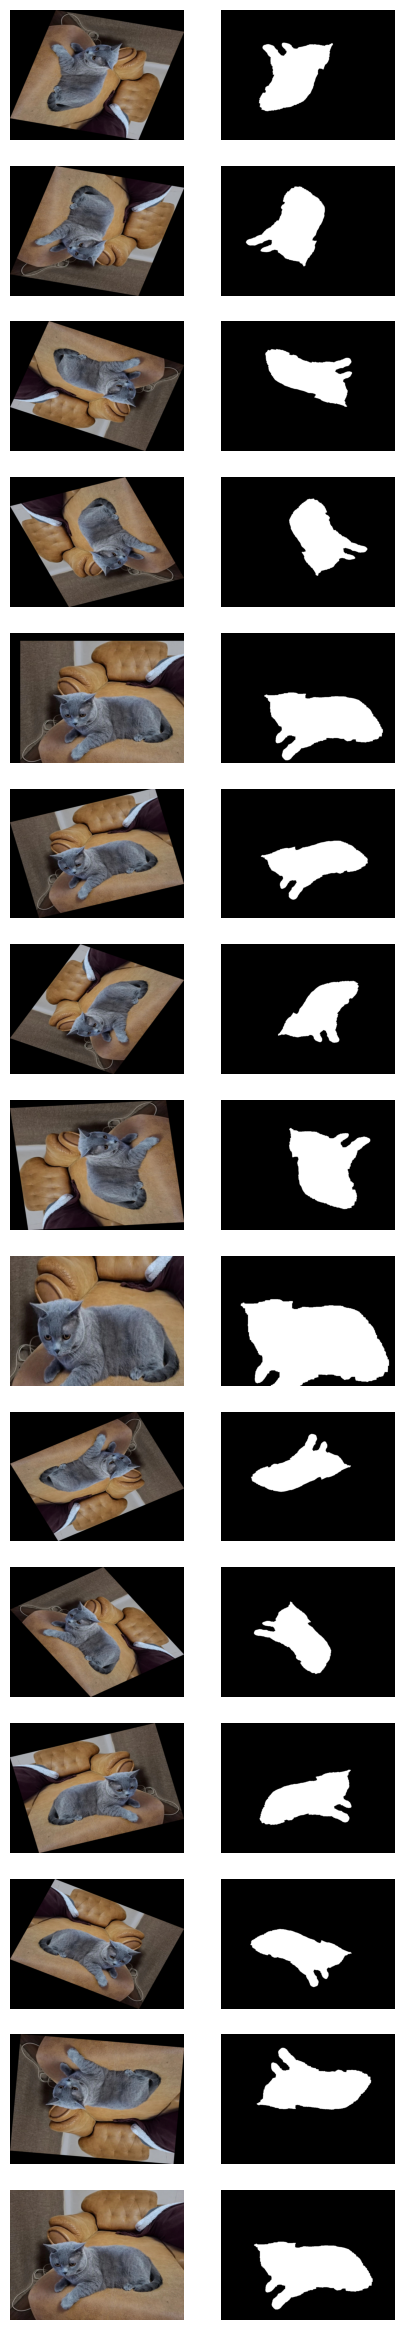

In [22]:
transformer = AugmentationGenerator(random_state=56)
ar_image, ar_mask = transformer.transform(image_rgb, clean_cat_mask, app_count=15)

fig, axis = plt.subplots(15, 2, figsize= (5, 30))
#axis = axis.flatten()

for i in range(min(15, len(ar_image))):
    axis[i][0].imshow(ar_image[i])
    axis[i][1].imshow(ar_mask[i], cmap="gray")
    axis[i][0].axis("off")
    axis[i][1].axis("off")

plt.show()
